Dataset loaded successfully!
Original Shape: (900, 16)

Features used:
['node_id', 'x', 'y', 'speed', 'battery_level', 'cpu_usage', 'memory_usage', 'signal_strength', 'packet_loss', 'latency']

Final Dataset Shape: (900, 10)

Target Distribution:
faulty
0    869
1     31
Name: count, dtype: int64

Training Data: (720, 10)
Testing Data : (180, 10)

Random Forest training completed!

RANDOM FOREST PERFORMANCE
Accuracy  : 0.9667 (96.67%)
Precision : 0.5000 (50.00%)
Recall    : 1.0000 (100.00%)
F1 Score  : 0.6667 (66.67%)
ROC-AUC   : 0.9828 (98.28%)

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98       174
     Failure       0.50      1.00      0.67         6

    accuracy                           0.97       180
   macro avg       0.75      0.98      0.82       180
weighted avg       0.98      0.97      0.97       180



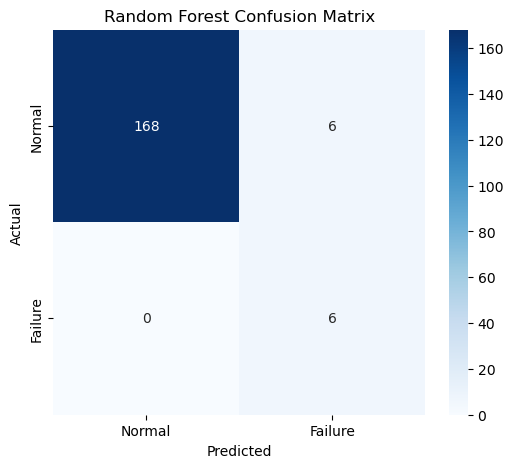


Feature Importance:
           Feature  Importance
9          latency    0.253430
8      packet_loss    0.230982
7  signal_strength    0.209507
1                x    0.111124
3            speed    0.107051
5        cpu_usage    0.055895
6     memory_usage    0.021054
2                y    0.008910
0          node_id    0.002047
4    battery_level    0.000000


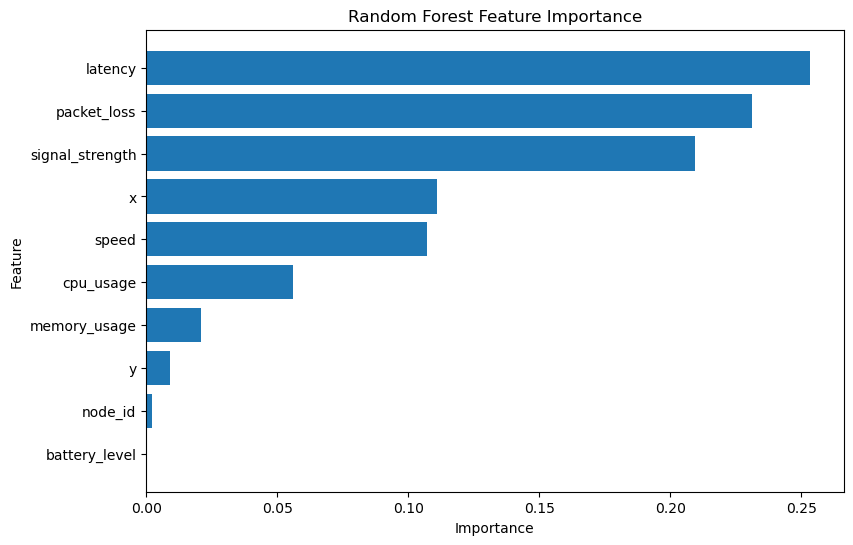

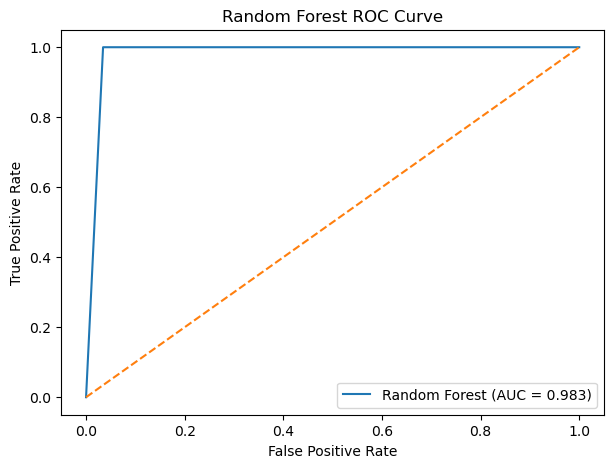


Prediction Results:
     node_id           x           y     speed  battery_level  cpu_usage  \
217        8  242.317496  230.092342  7.836423          100.0  12.827423   
431        2  947.204625  777.381163  1.754116          100.0  18.943035   
860        1  626.674110  676.296135  8.910633          100.0   8.744783   
106        7    4.707795  421.890941  9.233211          100.0   3.785949   
513        4  307.989899  582.533037  4.634219          100.0   0.479666   
504        5  359.996967  162.000484  6.028259          100.0  23.600763   
721        2  951.637597  763.701034  1.754116          100.0  14.549272   
314        5  357.462237  183.004987  6.028259          100.0   8.196874   
477        8  277.344203  205.671051  7.836423          100.0  24.037549   
595        6  517.028063   21.113880  4.951567          100.0   8.493257   

     memory_usage  signal_strength  packet_loss    latency  Actual_Failure  \
217      5.274929        14.854282     0.851457  58.201486      

In [1]:
# ============================================================
# ASIF AI PROJECT - RANDOM FOREST FAILURE PREDICTION
# ============================================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# ============================================================
# 2. LOAD DATASET
# ============================================================

file_path = "node_health_failure_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Original Shape:", df.shape)

# ============================================================
# 3. DATA PREPROCESSING
# ============================================================

# Remove unwanted column
df = df.drop(columns=["Unnamed: 15"], errors="ignore")

# Remove duplicate rows
df = df.drop_duplicates()

# Convert target to numeric
df["faulty"] = pd.to_numeric(
    df["faulty"],
    errors="coerce"
)

# Remove rows where target is missing
df = df.dropna(subset=["faulty"])

# Convert target to integer
df["faulty"] = df["faulty"].astype(int)

# ============================================================
# 4. SELECT FEATURES
# ============================================================

features = [
    "node_id",
    "x",
    "y",
    "speed",
    "battery_level",
    "cpu_usage",
    "memory_usage",
    "signal_strength",
    "packet_loss",
    "latency"
]

X = df[features].copy()
y = df["faulty"].copy()

# Handle missing feature values
X = X.fillna(X.median(numeric_only=True))

print("\nFeatures used:")
print(features)

print("\nFinal Dataset Shape:", X.shape)

print("\nTarget Distribution:")
print(y.value_counts())

# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data :", X_test.shape)

# ============================================================
# 6. CREATE RANDOM FOREST MODEL
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# ============================================================
# 7. TRAIN MODEL
# ============================================================

rf_model.fit(X_train, y_train)

print("\nRandom Forest training completed!")

# ============================================================
# 8. PREDICTION
# ============================================================

y_pred = rf_model.predict(X_test)

# Probability of FAILURE (class 1)
y_probability = rf_model.predict_proba(X_test)[:, 1]

# ============================================================
# 9. EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("\n" + "=" * 50)
print("RANDOM FOREST PERFORMANCE")
print("=" * 50)

print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall    : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 Score  : {f1:.4f} ({f1*100:.2f}%)")
print(f"ROC-AUC   : {roc_auc:.4f} ({roc_auc*100:.2f}%)")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Failure"],
        zero_division=0
    )
)

# ============================================================
# 10. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Failure"],
    yticklabels=["Normal", "Failure"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# 11. FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)

plt.figure(figsize=(9, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# ============================================================
# 12. ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

# ============================================================
# 13. CREATE PREDICTION OUTPUT
# ============================================================

prediction_output = X_test.copy()

prediction_output["Actual_Failure"] = y_test.values

prediction_output["Failure_Prediction"] = y_pred

prediction_output["Failure_Probability"] = y_probability

prediction_output["Failure_Probability_Percent"] = (
    y_probability * 100
)

print("\nPrediction Results:")
print(prediction_output.head(10))

# Save predictions
prediction_output.to_csv(
    "random_forest_predictions.csv",
    index=False
)

# ============================================================
# 14. SAVE TRAINED MODEL
# ============================================================

joblib.dump(
    rf_model,
    "random_forest_failure.pkl"
)

print("\nModel saved as:")
print("random_forest_failure.pkl")

# ============================================================
# 15. LOAD MODEL AGAIN AND TEST
# ============================================================

loaded_model = joblib.load(
    "random_forest_failure.pkl"
)

test_predictions = loaded_model.predict(X_test)

test_probabilities = loaded_model.predict_proba(
    X_test
)[:, 1]

loaded_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print("\nLoaded Model Accuracy:",
      f"{loaded_accuracy*100:.2f}%")

# ============================================================
# 16. FAILURE PREDICTION FUNCTION
# ============================================================

def predict_failure(
    node_id,
    x,
    y,
    speed,
    battery_level,
    cpu_usage,
    memory_usage,
    signal_strength,
    packet_loss,
    latency
):

    input_data = pd.DataFrame([{
        "node_id": node_id,
        "x": x,
        "y": y,
        "speed": speed,
        "battery_level": battery_level,
        "cpu_usage": cpu_usage,
        "memory_usage": memory_usage,
        "signal_strength": signal_strength,
        "packet_loss": packet_loss,
        "latency": latency
    }])

    probability = loaded_model.predict_proba(
        input_data
    )[0][1]

    prediction = loaded_model.predict(
        input_data
    )[0]

    if prediction == 1:
        status = "Failure"
    else:
        status = "Normal"

    return {
        "Failure Probability": round(
            float(probability), 4
        ),
        "Failure Probability (%)": round(
            float(probability * 100), 2
        ),
        "Failure Prediction": status
    }

# ============================================================
# 17. TEST NEW NODE
# ============================================================

result = predict_failure(
    node_id=5,
    x=50,
    y=50,
    speed=10,
    battery_level=30,
    cpu_usage=80,
    memory_usage=75,
    signal_strength=-85,
    packet_loss=15,
    latency=100
)

print("\n" + "=" * 50)
print("NEW NODE FAILURE PREDICTION")
print("=" * 50)

print("Failure Probability:",
      result["Failure Probability"])

print("Failure Probability (%):",
      result["Failure Probability (%)"])

print("Failure Prediction:",
      result["Failure Prediction"])

# ============================================================
# 18. SAVE MODEL INFORMATION
# ============================================================

model_info = {
    "model": "Random Forest Classifier",
    "purpose": "MANET Failure Prediction",
    "features": features,
    "target": "faulty",
    "outputs": [
        "Failure Probability",
        "Failure Prediction"
    ],
    "n_estimators": 200,
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "roc_auc": float(roc_auc)
}

joblib.dump(
    model_info,
    "random_forest_model_info.pkl"
)

# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 60)
print("       RANDOM FOREST COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nGenerated files:")
print("1. random_forest_failure.pkl")
print("2. random_forest_model_info.pkl")
print("3. random_forest_predictions.csv")

print("\nOutputs:")
print("✓ Failure Probability")
print("✓ Failure Prediction")
print("✓ Accuracy")
print("✓ Precision")
print("✓ Recall")
print("✓ F1 Score")
print("✓ ROC-AUC")
print("✓ Confusion Matrix")
print("✓ Feature Importance")
print("✓ ROC Curve")